In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/srikruthin/comment-submission-model/ensemble_model.pkl
/kaggle/input/datasets/srikruthin/comment-submission-model/char_tfidf.pkl
/kaggle/input/datasets/srikruthin/comment-submission-model/word_tfidf.pkl
/kaggle/input/datasets/srikruthin/comment-submission-model/X_test_final.npz
/kaggle/input/datasets/srikruthin/sub-folder/X_test_final2.npz
/kaggle/input/datasets/srikruthin/sub-folder/ensemble2_comb.pkl
/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


# Libraries

In [ ]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler,OneHotEncoder


# Dummy prediction

#### a dummy prediction is initially done for the given dataset

In [ ]:
# import pandas as pd
# from sklearn.dummy import DummyClassifier
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score
# ch = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
# df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
# sample_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")
# df.head()
# X = df[['comment']]
# y = df['label']


# X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# model = DummyClassifier()

# model.fit(X_train,y_train)

# y_pred = model.predict(X_test)
# print("accuracy_score",accuracy_score(y_pred,y_test))


# sub_pred = model.predict(ch[["if_2"]])
# submission = pd.DataFrame({
#     "ID": sample_df["ID"],
#     "label": sub_pred
# }
# )
# submission.to_csv("submission.csv", index=False)

# Data Loading
## loading train and test data

In [ ]:

train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test  = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")

In [ ]:
# Checking shape of training and testing data

print("shape of train",train.shape)
print("shape of test",test.shape)

shape of train (198000, 15)
shape of test (102000, 14)


In [ ]:
# # prints first 5 rows

print(train.head())

                       created_date  post_id  emoticon_1  emoticon_2  \
0  2024-01-18 08:43:57.397508+00:00       73           0           0   
1  2024-03-24 21:43:11.490017+00:00       39           0           0   
2  2024-04-24 20:32:17.014931+00:00       31           0           1   
3  2023-05-28 22:00:14.214527+00:00       39           0           0   
4  2023-09-09 23:12:05.689498+00:00       39           0           0   

   emoticon_3  upvote  downvote  if_1  if_2 race religion gender  disability  \
0           0       0         1     0    10  NaN      NaN    NaN       False   
1           0       6         0     0     4  NaN      NaN    NaN       False   
2           1       0         0     0    10  NaN      NaN    NaN       False   
3           0       5         0     0    10  NaN      NaN    NaN       False   
4           0       0         0     0    10  NaN      NaN    NaN       False   

                                             comment  label  
0  She might be a bright

In [ ]:
train.dtypes

created_date    object
post_id          int64
emoticon_1       int64
emoticon_2       int64
emoticon_3       int64
upvote           int64
downvote         int64
if_1             int64
if_2             int64
race            object
religion        object
gender          object
disability        bool
comment         object
label            int64
dtype: object

In [ ]:
train.info() # summary of the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


# Identifying Missing Values

In [ ]:
train.isnull().sum()

created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64

#### using is null() function we found :
1. race has 145423 null values
2. race has 145423 null values
3. gender has 145423 null values

# Handling missing values

In [ ]:
num_cols = ['upvote','downvote','emoticon_1','emoticon_2','emoticon_3','if_1','if_2']
for col in num_cols:
    if train[col].isnull().sum()>0:
        train[col].fillna(train[col].mean(),inplace=True)

cat_cols = train.select_dtypes(include=['object']).columns
for col in cat_cols:
    if train[col].isnull().sum()>0:
        train[col].fillna(train[col].mode()[0],inplace=True)

/tmp/ipykernel_55/1983363543.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train[col].fillna(train[col].mode()[0],inplace=True)


In [ ]:
print(train.isnull().sum())

created_date    0
post_id         0
emoticon_1      0
emoticon_2      0
emoticon_3      0
upvote          0
downvote        0
if_1            0
if_2            0
race            0
religion        0
gender          0
disability      0
comment         0
label           0
dtype: int64


# Descriptive statistics
#### observations
1. In emoticon_1, emoticon_2, emoticon_3 the 25%, 50%, 75% values are all 0 .Mean is very small
2. In Upvote Feature Most values are low, Few values are very high.it indicates outliers
3. if_1, if_2 have high std,so data is widely spread and not consistent


In [ ]:
train.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


# EDA(Exploratory Data Analysis)


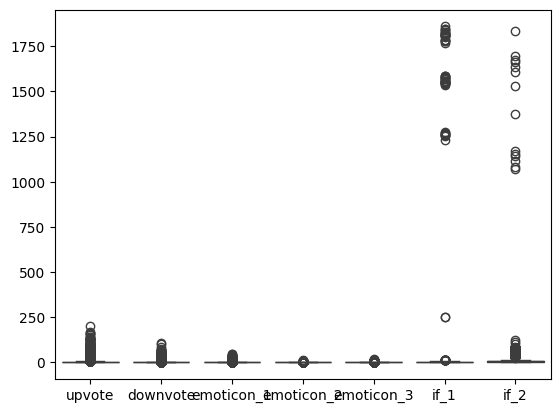

In [ ]:
# Boxplot to see if outliers exisit
sns.boxplot(data=train[['upvote','downvote','emoticon_1','emoticon_2','emoticon_3','if_1','if_2']])
plt.show()

#### From boxplot

1. Extreme outliers observed in if_1 and if_2
2. emoticon_1, emoticon_2, emoticon_3 have small values
3. In upvote,downvote also many have low values,few high values

#

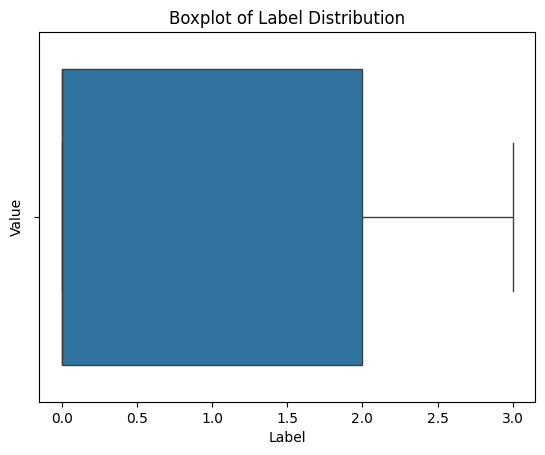

In [ ]:
# Boxplot for label

sns.boxplot(x=train['label'])
plt.xlabel("Label")
plt.ylabel("Value")
plt.title("Boxplot of Label Distribution")
plt.show()

###
1. In the above plot it has no outliers
2. Values are between 0 to 3.
3. label is the target variable

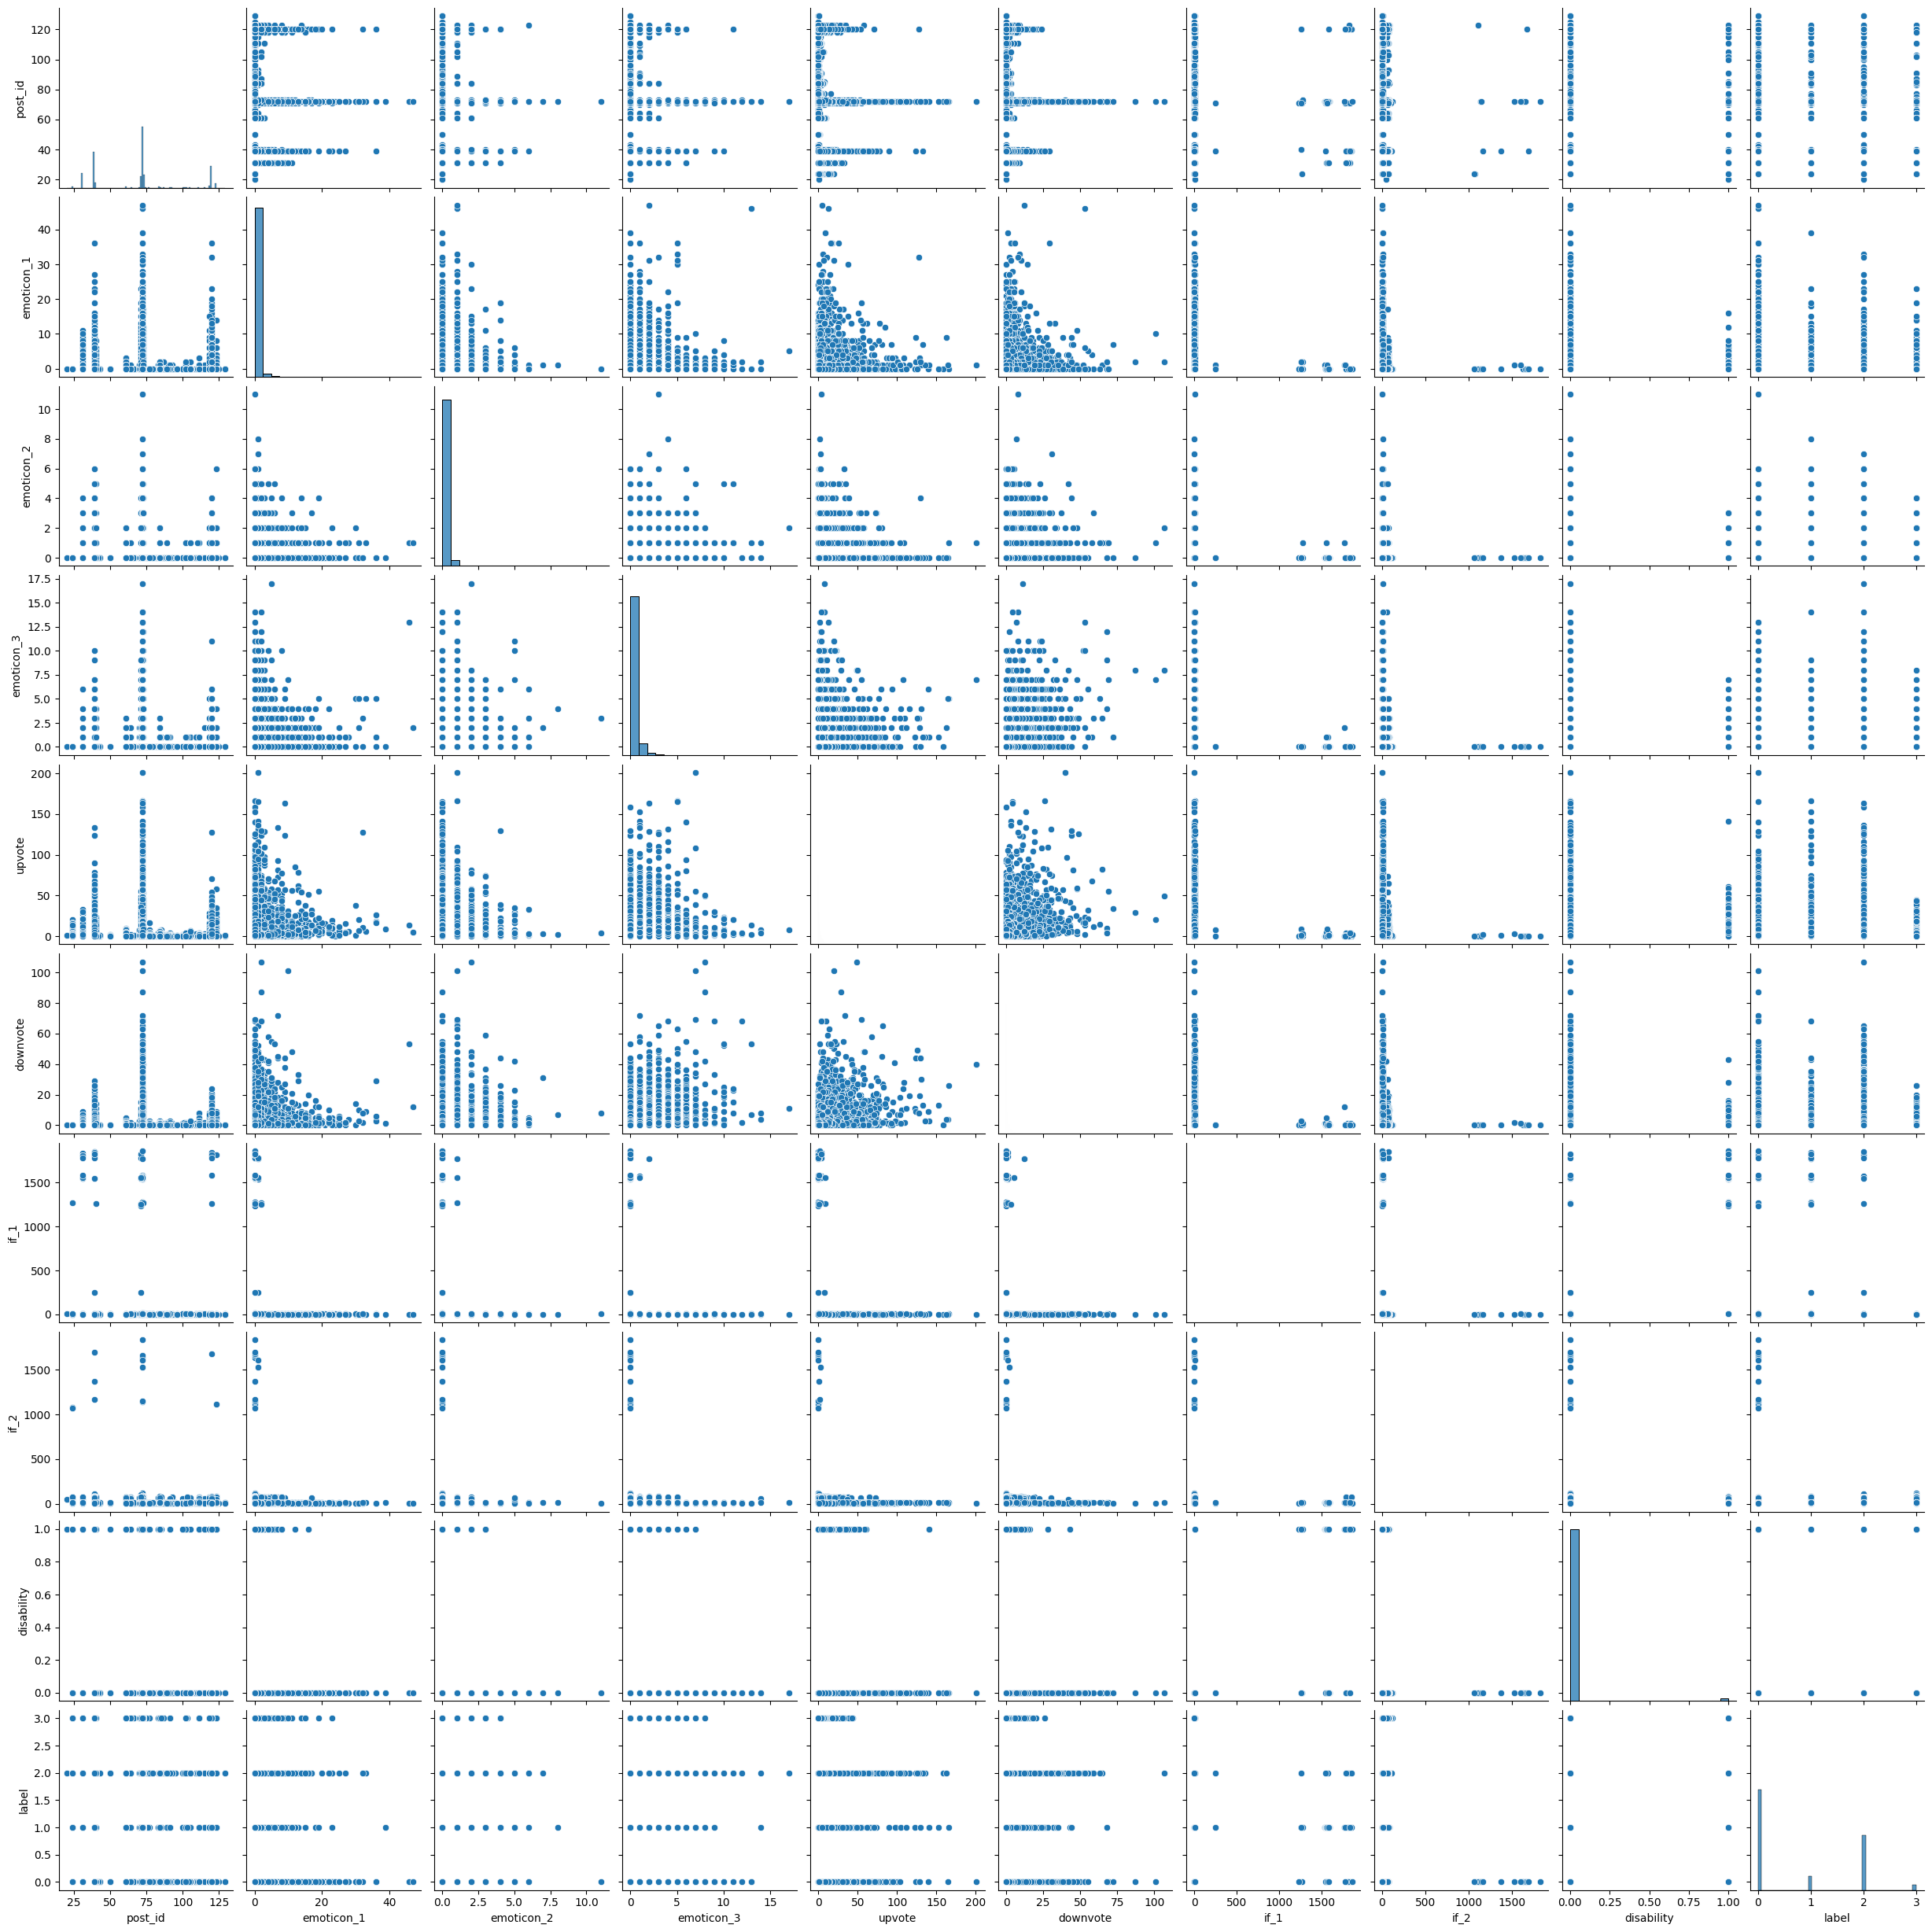

In [ ]:

sns.pairplot(train)
# pairplot it helps in showing relationship between multiple features of trainig data.

/tmp/ipykernel_55/3968594579.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="label",data=train,palette='viridis')


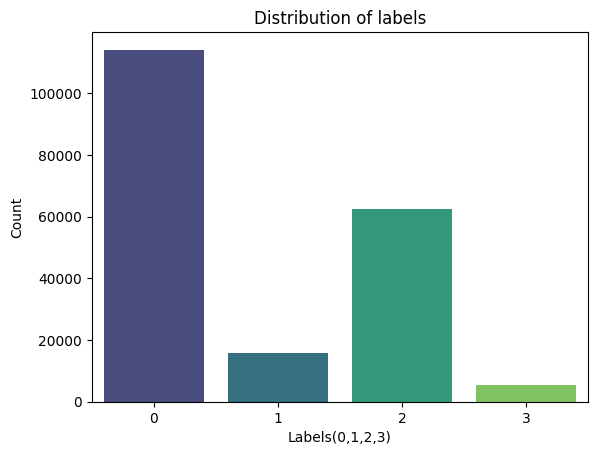

In [ ]:
sns.countplot(x="label",data=train,palette='viridis')
plt.title("Distribution of labels")
plt.xlabel("Labels(0,1,2,3)")
plt.ylabel("Count")
plt.show()

##### From the above plot
1. Label 0 has highest frequency,next is label 2
2. Among the 4 labels,label 3 has lowest frequency
3. We can see class imbalance
4. As there are 4 categories it is multi-class classification problem

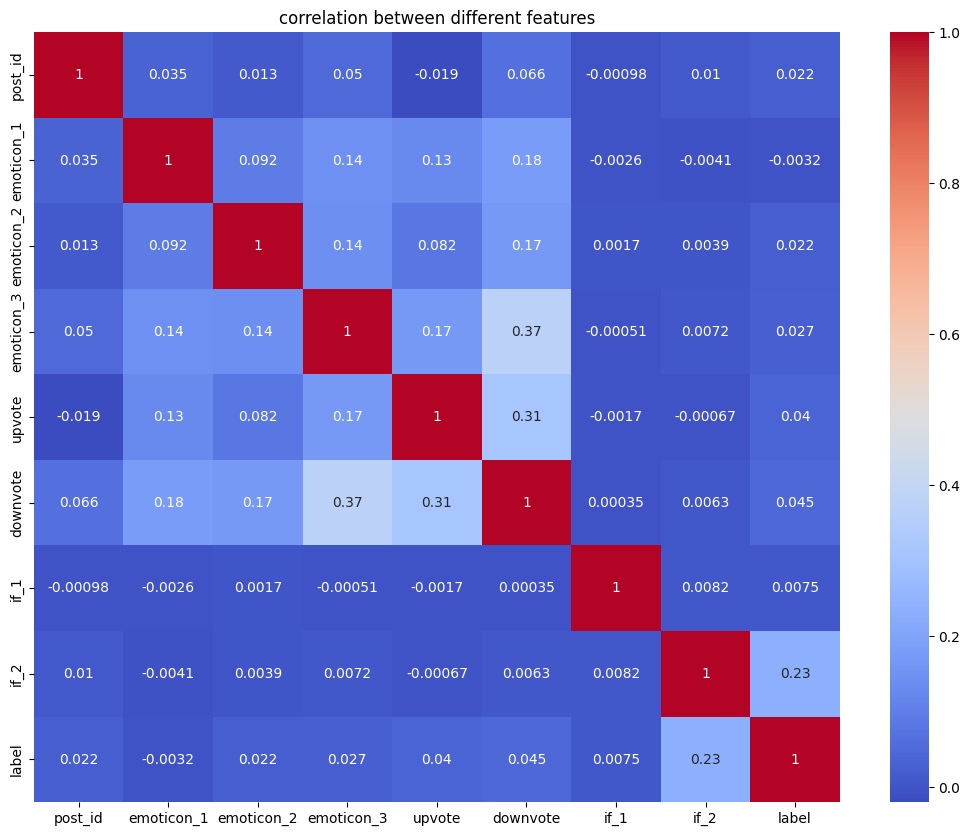

In [ ]:
# Heatmap
train_num = train.select_dtypes(include=['int64','float64']).columns
corr = train[train_num].corr()
plt.figure(figsize=(13,10))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("correlation between different features")
plt.show()

#### From heatmap:
1. Most correlations  are  near to 0.
2. In upvote and downvote the correlation is 0.31
3. post_id has almost 0 correlation with all features

# Feature distribution

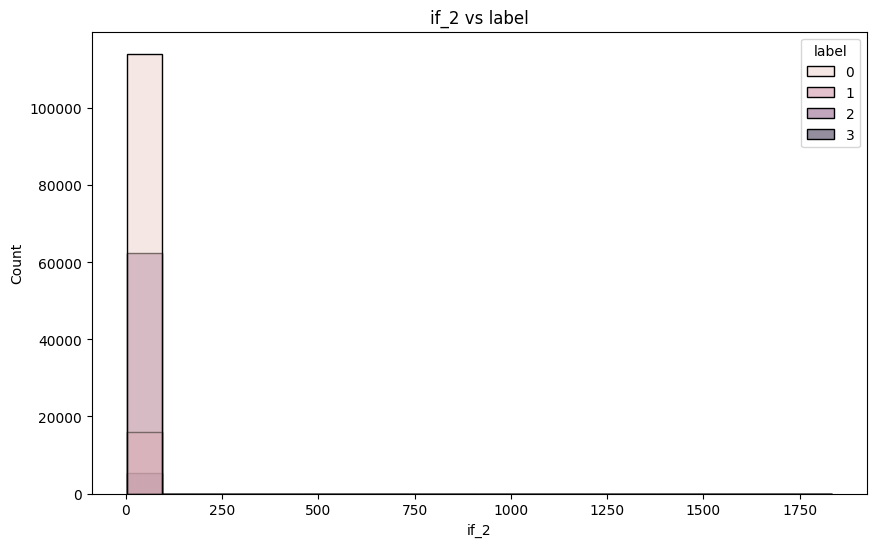

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(data=train,x="if_2",hue="label",bins=20)
plt.title("if_2 vs label")
plt.xlabel("if_2")
plt.ylabel("Count")
plt.show()

####

- if_2 is highly skewed
- All labels (0,1,2,3) overlap heavily
-  No clear Seperation

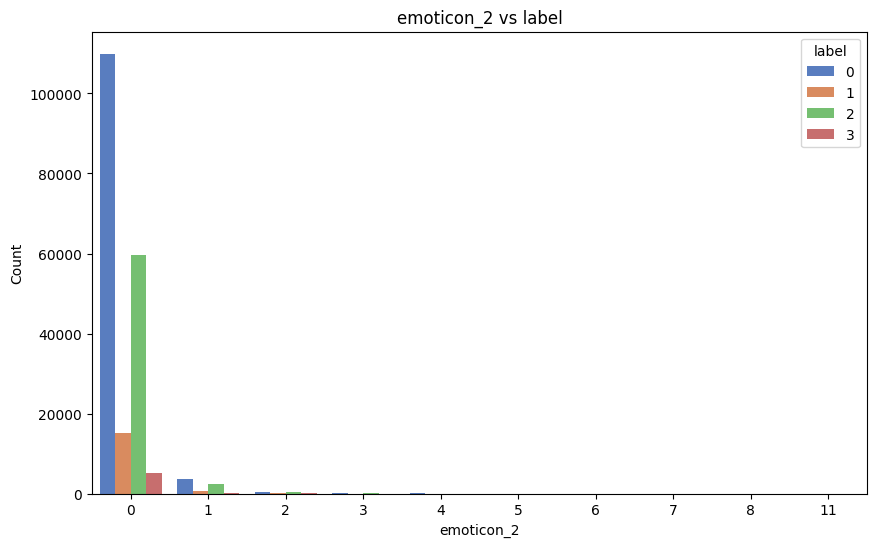

In [ ]:

plt.figure(figsize=(10,6))
sns.countplot(data=train,x="emoticon_2",hue="label",palette='muted')
plt.title("emoticon_2 vs label")
plt.xlabel("emoticon_2")
plt.ylabel("Count")
plt.show()

###
- Very high frequency at 0
- All labels overlap at same values
- features are weak individually

# Important Insights
1. It is multi-class classification problem
2. Distribution of labels is imbalanced (Label 0 has highest,Where as label 3 has lowest)
3. post_id has almost 0 correlation with all features so it can be dropped
4. Acc to EDA analysis, it is understood that  the target variable mostly depends on the text feature(comment)
5. Need to perform feature tf-idf(feature engineering) technique

In [ ]:
# Dropping the columns post_id and created_date from training data

train.drop(['post_id','created_date'],axis=1,inplace=True)
print(train)

        emoticon_1  emoticon_2  emoticon_3  upvote  downvote  if_1  if_2  \
0                0           0           0       0         1     0    10   
1                0           0           0       6         0     0     4   
2                0           1           1       0         0     0    10   
3                0           0           0       5         0     0    10   
4                0           0           0       0         0     0    10   
...            ...         ...         ...     ...       ...   ...   ...   
197995           0           0           0       2         0     0     4   
197996           0           0           0       1         0     0    10   
197997           0           0           0       0         0     0    10   
197998           0           1           1       5         7     4    10   
197999           0           0           0       1         0     4     4   

         race religion gender  disability  \
0        none     none   none       False 

# train-test-split of data

In [ ]:
X = train.drop(columns=['label'])
y = train['label']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=24)

print(X_train)
print(X_test)


        emoticon_1  emoticon_2  emoticon_3  upvote  downvote  if_1  if_2  \
153714           0           0           0       0         2     0    10   
182012           0           0           0       0         0     4     4   
91494            0           0           1       0         6     0    11   
38211            0           0           0       1         0     0    10   
124823           0           0           0       3         0     4     4   
...            ...         ...         ...     ...       ...   ...   ...   
143483           0           0           0       2         1     0     6   
6500             1           1           0       7         0     4    10   
152705           0           0           0       1         0     0     4   
190609           0           0           0       0         0     0    10   
899              1           0           5       3         0     0    10   

         race religion gender  disability  \
153714   none     none   none       False 

# Apply Standard Scaler
#### apply scaling to numerical features ['upvote','downvote','emoticon_1','emoticon_2','emoticon_3','if_1','if_2']

In [ ]:
numerical_fea = ['upvote','downvote','emoticon_1','emoticon_2','emoticon_3','if_1','if_2']

scaler = StandardScaler()
X_train[numerical_fea] = scaler.fit_transform(X_train[numerical_fea])
X_test[numerical_fea] = scaler.transform(X_test[numerical_fea])


In [ ]:
print(X_train.columns)

Index(['emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1',
       'if_2', 'race', 'religion', 'gender', 'disability', 'comment'],
      dtype='object')


# Encoding

In [ ]:
categorical_fea = ['race','religion','gender','disability']
X_train = pd.get_dummies(X_train, columns=categorical_fea, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_fea, drop_first=True)


In [ ]:
X_train['comment'] = X_train['comment'].fillna("") # to fill with empty for nan-values
X_test['comment'] = X_test['comment'].fillna("")

# Feature enginerring

### We will be using feature engineering for text like comment

In [ ]:
# Cleaning of text(column) feature

import re  # regular expression library.
def error_clean(sentence):
    sentence = sentence.lower()
    sentence = re.sub(r"http\S+","",sentence) # helps to remove url
    sentence = re.sub(r"[^a-zA-Z\s]","",sentence) # keeps letter,spaces  and removes Numbers,special characters
    sentence = re.sub(r"\s+"," ",sentence) # replaces multiple consective spaces
    return sentence
X_train['train_comment'] = X_train['comment'].apply(error_clean)
X_test['test_comment'] =  X_test['comment'].apply(error_clean)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
# using tf-idf to give high weightage to words that are important
wr_tfidf = TfidfVectorizer(
    stop_words='english',
    analyzer='word', # using word to word
    ngram_range=(1,2),
    max_features=60000,
    min_df=2, # minimum document frequency
    max_df=0.9,
    sublinear_tf=True # scales the term frequency
)

wr_train = wr_tfidf.fit_transform(X_train['train_comment'])
wr_test = wr_tfidf.transform(X_test['test_comment'])

In [ ]:
# using character level tf-idf
ch_tfidf = TfidfVectorizer(
    analyzer='char_wb', # to process text at character level
    ngram_range=(3,6), # patterns,sequences
    max_features=80000,
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)

ch_train = ch_tfidf.fit_transform(X_train['train_comment'])
ch_test = ch_tfidf.transform(X_test['test_comment'])

In [ ]:
from scipy.sparse import hstack
# hstack used to combine sparse matrices
final_htif_train = hstack([wr_train, ch_train]) # combines both into one large feature matrix
final_htif_test = hstack([wr_test, ch_test])

# Model-1 Logistic  Regression

In [ ]:
# using logistic regression

from sklearn.metrics import accuracy_score
lr = LogisticRegression(C=2,max_iter=5000,random_state=32)
lr.fit(final_htif_train ,y_train)

LogisticRegression(C=2, max_iter=5000, random_state=32)

# Evaluation metrics for logistic regression

### Accuracy
### Confusion matrix
### Classification report

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report
lr_predict_train = lr.predict(final_htif_train)
lr_predict_test = lr.predict(final_htif_test)
print("train_accuracy score",accuracy_score(lr_predict_train,y_train))
print("test_accuracy score",accuracy_score(lr_predict_test,y_test))

train_accuracy score 0.8916982323232323
test_accuracy score 0.7993434343434344


In [ ]:
print("confusion_matrix(training)\n",confusion_matrix(lr_predict_train,y_train))
print("confusion_matrix(testing)\n",confusion_matrix(lr_predict_test,y_test))

confusion_matrix(training)
 [[86223  1875  7224  1289]
 [  855 10028   549    90]
 [ 3920   759 42164   226]
 [  244    37    87  2830]]
confusion_matrix(testing)
 [[20484   912  3262   506]
 [  389  1930   266    28]
 [ 1925   346  8835    95]
 [  133    31    53   405]]


In [ ]:
print("classification report(training)\n",classification_report(lr_predict_train,y_train))
print("classification report(testing)\n",classification_report(lr_predict_test,y_test))

classification report(training)
               precision    recall  f1-score   support

           0       0.94      0.89      0.92     96611
           1       0.79      0.87      0.83     11522
           2       0.84      0.90      0.87     47069
           3       0.64      0.88      0.74      3198

    accuracy                           0.89    158400
   macro avg       0.80      0.89      0.84    158400
weighted avg       0.90      0.89      0.89    158400

classification report(testing)
               precision    recall  f1-score   support

           0       0.89      0.81      0.85     25164
           1       0.60      0.74      0.66      2613
           2       0.71      0.79      0.75     11201
           3       0.39      0.65      0.49       622

    accuracy                           0.80     39600
   macro avg       0.65      0.75      0.69     39600
weighted avg       0.81      0.80      0.80     39600



# Hyperparameter tuning

In [ ]:
from sklearn.metrics import accuracy_score
lr = LogisticRegression(C=2,max_iter=5000,solver =  'liblinear')
lr.fit(final_htif_train ,y_train)

LogisticRegression(C=2, max_iter=5000, solver='liblinear')

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

hyper_para = {
    "max_iter":[1000,2000,3000,5000],
    'solver': ['lbfgs', 'liblinear'], # Using RandomizedSearchCV for hyperparameter tuning
    'C':[0.5,1,2,3,1.5]
}

random_model = RandomizedSearchCV(lr,param_distributions=hyper_para,n_iter=5,scoring='accuracy',cv=3,n_jobs=-1)
random_model.fit(final_htif_train, y_train)
print("Best Parameters:", random_model.best_params_)

Best Parameters: {'solver': 'liblinear', 'max_iter': 5000, 'C': 2}


#### Retraining the model after performing hyper-tuning

In [ ]:
lr_predict_train = lr.predict(final_htif_train)
lr_predict_test = lr.predict(final_htif_test)
print("train_accuracy score",accuracy_score(lr_predict_train,y_train))
print("test_accuracy score",accuracy_score(lr_predict_test,y_test))

train_accuracy score 0.8707891414141414
test_accuracy score 0.800959595959596


### Observation
-  Classification report for testing data: Class 0 and Class 2 have good precision, recall, and F1-score.
-  Before hyperparameter tuning Training_score = 0.89 and Validation_score = 0.799.
-  After hyperparameter tuning Training_score = 0.87 and Validation_score = 0.800.

# Model-2 SVM


In [ ]:
from sklearn.svm import LinearSVC
svm_model = LinearSVC(C=0.3,
    loss='squared_hinge',
    class_weight='balanced',
    max_iter=12000)
svm_model.fit(final_htif_train,y_train)
svm_predict_train = svm_model.predict(final_htif_train)
svm_predict_test = svm_model.predict(final_htif_test)

# Evaluation metrics for SVM
### Accuracy
### Confusion matrix
### Classification report

In [ ]:

print("train_accuracy score",accuracy_score(svm_predict_train,y_train))
print("test_accuracy score",accuracy_score(svm_predict_test,y_test))

train_accuracy score 0.8985542929292929
test_accuracy score 0.80239898989899


In [ ]:
print("confusion_matrix(training)\n",confusion_matrix(svm_predict_train,y_train))
print("confusion_matrix(testing)\n",confusion_matrix(svm_predict_test,y_test))

confusion_matrix(training)
 [[83001   292  5724    34]
 [ 1938 12110  1097    23]
 [ 5371   248 42859    17]
 [  932    49   344  4361]]
confusion_matrix(testing)
 [[19685   511  2661   313]
 [  730  2364   448    40]
 [ 2108   281  9134    89]
 [  408    63   173   592]]


In [ ]:
print("classification report(training)\n",classification_report(svm_predict_train,y_train))
print("classification report(testing)\n",classification_report(svm_predict_test,y_test))


classification report(training)
               precision    recall  f1-score   support

           0       0.91      0.93      0.92     89051
           1       0.95      0.80      0.87     15168
           2       0.86      0.88      0.87     48495
           3       0.98      0.77      0.86      5686

    accuracy                           0.90    158400
   macro avg       0.93      0.85      0.88    158400
weighted avg       0.90      0.90      0.90    158400

classification report(testing)
               precision    recall  f1-score   support

           0       0.86      0.85      0.85     23170
           1       0.73      0.66      0.70      3582
           2       0.74      0.79      0.76     11612
           3       0.57      0.48      0.52      1236

    accuracy                           0.80     39600
   macro avg       0.73      0.69      0.71     39600
weighted avg       0.80      0.80      0.80     39600



# Hyperparameter tuning of SVM

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import LinearSVC

params = {'C':[0.01,0.05,0.1,0.3,0.5,1,2]}

svm_search = RandomizedSearchCV( # Using RandomizedSearchCV for hyperparameter tuning
    svm_model,
    params,
    cv=5,
    n_jobs=1
)

svm_search.fit(final_htif_train, y_train)

print(svm_search.best_params_)


{'C': 0.1}


In [ ]:
from sklearn.svm import LinearSVC
svm_model = LinearSVC(C=0.1,
    loss='squared_hinge',
    class_weight='balanced',
    max_iter=12000)
svm_model.fit(final_htif_train,y_train)
svm_predict_train = svm_model.predict(final_htif_train)
svm_predict_test = svm_model.predict(final_htif_test)
print("train_accuracy score",accuracy_score(svm_predict_train,y_train))
print("test_accuracy score",accuracy_score(svm_predict_test,y_test))

train_accuracy score 0.8642929292929293
test_accuracy score 0.8034343434343434


### Observation

- Based on the testing data confusion matrix,the model performs well on the majority classes (Class 0 and Class 2)
- The model struggles with the minority class (Class 3), showing low recall and F1-score
- There is a drop in performance from training to testing, indicating slight overfitting.
- After hyperparameter tuning train_score : 0.86 and test_score : 0.8034

# Model-3 Naive bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB

MNB_model =  MultinomialNB(alpha=0.1)
MNB_model.fit(final_htif_train,y_train)
MNB_predict_train = MNB_model.predict(final_htif_train)
MNB_predict_test = MNB_model.predict(final_htif_test)

# Evaluation metrics for naive bayes
### Accuracy
### Confusion matrix
### Classification report

In [ ]:

print("train_accuracy score",accuracy_score(MNB_predict_train,y_train))
print("test_accuracy score",accuracy_score(MNB_predict_test,y_test))


train_accuracy score 0.7679040404040404
test_accuracy score 0.7207575757575757


In [ ]:
print("confusion_matrix(training)\n",confusion_matrix(MNB_predict_train,y_train))
print("confusion_matrix(testing)\n",confusion_matrix(MNB_predict_test,y_test))

confusion_matrix(training)
 [[72135  1384 10286   725]
 [ 4947 10291  2784   245]
 [12272   888 36073   328]
 [ 1888   136   881  3137]]
confusion_matrix(testing)
 [[17523   529  3180   324]
 [ 1288  2283   769    76]
 [ 3612   357  8229   127]
 [  508    50   238   507]]


In [ ]:

print("classification report(training)\n",classification_report(MNB_predict_train,y_train))
print("classification report(testing)\n",classification_report(MNB_predict_test,y_test))

classification report(training)
               precision    recall  f1-score   support

           0       0.79      0.85      0.82     84530
           1       0.81      0.56      0.66     18267
           2       0.72      0.73      0.72     49561
           3       0.71      0.52      0.60      6042

    accuracy                           0.77    158400
   macro avg       0.76      0.67      0.70    158400
weighted avg       0.77      0.77      0.76    158400

classification report(testing)
               precision    recall  f1-score   support

           0       0.76      0.81      0.79     21556
           1       0.71      0.52      0.60      4416
           2       0.66      0.67      0.67     12325
           3       0.49      0.39      0.43      1303

    accuracy                           0.72     39600
   macro avg       0.66      0.60      0.62     39600
weighted avg       0.72      0.72      0.72     39600



# Hyperparameter tuning of naive bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import RandomizedSearchCV
param_grid = {
    'alpha': [0.1, 0.5, 1, 1.5, 2],
    'fit_prior': [True, False]
}

nb = MultinomialNB()

random_nb = RandomizedSearchCV( # Using RandomizedSearchCV for hyperparameter tuning
    nb,
    param_grid,
    cv=5,
    scoring='accuracy'
)

random_nb.fit(final_htif_train, y_train)

print("Parameters:", random_nb.best_params_)


Parameters: {'fit_prior': True, 'alpha': 1}


In [ ]:
from sklearn.naive_bayes import MultinomialNB

MNB_model =  MultinomialNB(alpha=0.1,fit_prior = True)
MNB_model.fit(final_htif_train,y_train)
MNB_predict_train = MNB_model.predict(final_htif_train)
MNB_predict_test = MNB_model.predict(final_htif_test)
print("train_accuracy score",accuracy_score(MNB_predict_train,y_train))
print("test_accuracy score",accuracy_score(MNB_predict_test,y_test))


train_accuracy score 0.7679040404040404
test_accuracy score 0.7207575757575757


### Observation
- It has train_accuracy: 0.76 and test_accuracy: 0.72 Before hyperparameter tuning.
- Class 1 and Class 3 show poor recall
- Very low recall and F1-score for minority class (Class 3).  
- It has low accuracy compared to remainig two models

# Model-4
### using ensemble-from sklearn

In [ ]:
# performing with ensembel 1
# import joblib
# from scipy import sparse

# ensemble = joblib.load("/kaggle/input/datasets/srikruthin/comment-submission-model/ensemble_model.pkl")

# word_tfidf = joblib.load("/kaggle/input/datasets/srikruthin/comment-submission-model/word_tfidf.pkl")

# char_tfidf = joblib.load("/kaggle/input/datasets/srikruthin/comment-submission-model/char_tfidf.pkl")

# X_test_final = sparse.load_npz("/kaggle/input/datasets/srikruthin/comment-submission-model/X_test_final.npz")

In [ ]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from scipy.sparse import hstack, csr_matrix
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier

train = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input//comment-category-prediction-challenge/test.csv')





In [ ]:
print(train.shape)

(198000, 15)


In [ ]:
train['comment'] = train['comment'].fillna("")
test['comment'] = test['comment'].fillna("")


In [ ]:
X = train.drop('label', axis=1)
y = train['label']

X_train_full, X_val, y_train_full, y_val = train_test_split(
    X,y, test_size=0.2, random_state=42, stratify=train['label']
)

def error_clean(sentence):
    sentence = sentence.lower()
    sentence = re.sub(r"http\S+", "", sentence)
    sentence = re.sub(r"[^a-zA-Z\s]", "", sentence)
    sentence = re.sub(r"\s+", " ", sentence)
    return sentence

for df in [X_train_full, X_val, test]:
    df['clean_comment'] = df['comment'].apply(error_clean)

In [ ]:
for df in [X_train_full, X_val, test]:
    df['comment_len'] = df['comment'].str.len() # number of characters in each comment
    df['word_count'] = df['comment'].apply(lambda x: len(x.split()))

extra_features = [
    'emoticon_1','emoticon_2','emoticon_3',
    'upvote','downvote','if_1','if_2',
    'race','religion','gender','disability',
    'comment_len','word_count'
]

In [ ]:
for df in [X_train_full, X_val, test]:

    df['race'] = pd.to_numeric(df['race'], errors='coerce')
    df['religion'] = pd.to_numeric(df['religion'], errors='coerce')
    df['gender'] = pd.to_numeric(df['gender'], errors='coerce')
    df['disability'] = pd.to_numeric(df['disability'], errors='coerce')

for df in [X_train_full, X_val, test]:
    df[extra_features] = df[extra_features].fillna(0)

In [ ]:
# for df in [X_train_full, X_val, test]:
#     df[extra_features] = df[extra_features].astype(float)

In [ ]:

word_tfidf = TfidfVectorizer(stop_words='english', ngram_range=(1,2), max_features=20000, min_df=2, max_df=0.9, sublinear_tf=True)
char_tfidf = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,6), max_features=30000, min_df=2, max_df=0.9, sublinear_tf=True)

wr_train = word_tfidf.fit_transform(X_train_full['clean_comment'])
wr_val = word_tfidf.transform(X_val['clean_comment'])
wr_test = word_tfidf.transform(test['clean_comment'])

ch_train = char_tfidf.fit_transform(X_train_full['clean_comment'])
ch_val = char_tfidf.transform(X_val['clean_comment'])
ch_test = char_tfidf.transform(test['clean_comment'])

In [ ]:
from scipy.sparse import csr_matrix

X_train_final = hstack([
    wr_train,
    ch_train,
    csr_matrix(X_train_full[extra_features].values.astype(float))
])

X_val_final = hstack([
    wr_val,
    ch_val,
    csr_matrix(X_val[extra_features].values.astype(float))
])

X_test_final = hstack([
    wr_test,
    ch_test,
    csr_matrix(test[extra_features].values.astype(float))
])



In [ ]:
lgbm_model = LGBMClassifier(
    class_weight='balanced',
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)


In [ ]:

xgb_model = XGBClassifier(objective='multi:softmax', num_class=len(y_train_full.unique()),
                          n_estimators=200, learning_rate=0.1, max_depth=6,
                          subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)

In [ ]:
svm_model = LinearSVC(class_weight='balanced', max_iter=5000)

In [ ]:
log_model = LogisticRegression(class_weight='balanced', max_iter=5000, n_jobs=-1)

In [ ]:

ensemble = VotingClassifier(
    estimators=[('lgbm', lgbm_model), ('xgb', xgb_model), ('svm', svm_model), ('log', log_model)],
    voting='hard' # each model predicts a class , the class with the most common is taken.
)

ensemble.fit(X_train_final, y_train_full)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 67.123048 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7011897
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 49911
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


VotingClassifier(estimators=[('lgbm',
                              LGBMClassifier(class_weight='balanced',
                                             colsample_bytree=0.8, max_depth=6,
                                             n_estimators=200, n_jobs=-1,
                                             random_state=42, subsample=0.8)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.8, device=None,
                                            early_stopping_rounds=None,
                                            enable_categ...
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=6,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=200, n_jobs=-1,
                                            num_class=4, ...)),
                             ('svm',
                              LinearSVC(class_weight='balanced',
                                        max_iter=5000)),
                             ('log',
                              LogisticRegression(class_weight='balanced',
                                                 max_iter=5000, n_jobs=-1))])

In [ ]:
# import joblib

# joblib.dump(ensemble, "ensemble2_comb.pkl")
# print("finsihed")

finsihed


In [ ]:

y_pred_train = ensemble2.predict(X_train_final)
train_acc = accuracy_score(y_train_full, y_pred_train)


y_pred_val = ensemble2.predict(X_val_final)
val_acc = accuracy_score(y_val, y_pred_val)

#  accuracies of traing and testing
print("Training Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)

print("\nClassification Report (Training):\n", classification_report(y_train_full, y_pred_train))
print("\nClassification Report (Validation):\n", classification_report(y_val, y_pred_val))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training Accuracy: 0.933989898989899
Validation Accuracy: 0.9141414141414141

Classification Report (Training):
               precision    recall  f1-score   support

           0       0.98      0.95      0.97     91338
           1       0.79      0.93      0.85     12735
           2       0.91      0.91      0.91     49952
           3       0.76      0.88      0.82      4375

    accuracy                           0.93    158400
   macro avg       0.86      0.92      0.89    158400
weighted avg       0.94      0.93      0.94    158400


Classification Report (Validation):
               precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.72      0.85      0.78      3183
           2       0.89      0.89      0.89     12488
           3       0.64      0.72      0.68      1094

    accuracy                           0.91     39600
   macro avg       0.81      0.85      0.83     39600
weighted avg       0.92      0.91 

### Observation
- Achieves highest accuracy (0.91), showing best overall performance
- Class 1 and Class 3 show improved recall, indicating better learning of minority classes.
- Class 1 and Class 3 show improved recall, indicating better learning of minority classes.
- Got good accuracy compared to remaming 3 models

# Model Comparisons
- In this project, 4 models have been used: logistic regression, SVM, Naive Bayes, Ensemble(combination of logistic regression, SVM,lighbgm,xgboost)
- For label 3, when the F1 score improved, model accuracy improved. So, the F1 score played a role for labels.
- In the ensemble model, the text (comment) feature is combined with extra_features.
- In ensemble,it is combination of 4 models

 ## Logistic Regression
- Accuracy around 0.79  to 0.80 (moderate performance)
- Performs well on the majority of classes (Class 0 and Class 2)
- Struggles with minority class (Class 3)
- Slight overfitting observed
- Affected by class imbalance
  
## Support Vector Machine (SVM)
- Accuracy around 0.80–0.803
- Better generalization than Logistic Regression
- Good performance on the majority of classes
- Confusion between Class 0 and Class 2
- Poor performance on minority class (Class 3)

## Naive Bayes
- Lowest accuracy (0.72)
- Poor performance across all classes
- Low precision, recall, and F1-score
- High misclassification

## Ensemble
-  Combination of logistic regression, SVM,lighbgm,xgboost models
- Highest accuracy (~0.91) among all models
- Best performance across all classes
- Significant improvement in minority class (Class 3)
- Balanced precision, recall, and F1-score
- Good generalization with minimal overfitting

Among all the models, Ensemble is the best model. Performed well on testing data.
Naive Bayes is the  Underperforming model compared to all 4 models.
SVM(Support Vector Machine) performed a bit well than logistic regression.

# Test_data prediction with best model for final submission


In [ ]:
predictions = ensemble2.predict(X_test_final)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Ensemble is best one among the given models
submission = pd.DataFrame({
    "ID": range(1, len(predictions) + 1),
    "label": predictions
})

submission.to_csv("/kaggle/working/submission.csv", index=False)

print("Submission file ready!")

Submission file ready!


# Important Insights

1. The dataset is complex with different features.
2. In the dataset, Label 3 has very few samples compared to the remaining labels.
3. SVM and Logistic regression gave moderate performance.
4. Compared to Individual models ensemble provides good generalization.
5. Handling class imbalance is crucial for improving performance.
6. F1-score is a better metric than accuracy for imbalanced datasets.

In [ ]:
# import pandas as pd
# import joblib
# from scipy import sparse

# X_test = sparse.load_npz("/kaggle/input/datasets/srikruthin/sub-folder/X_test_final2.npz")
# model = joblib.load("/kaggle/input/datasets/srikruthin/sub-folder/ensemble2_comb.pkl")


# predictions = model.predict(X_test)


# submission = pd.DataFrame({
#     "ID": range(1, len(predictions)+1),
#     "label": predictions
# })


# submission.to_csv("/kaggle/working/submission.csv", index=False)

# print("Submission created")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Submission created
